### 1. Carga datos

In [2]:
import pandas as pd

In [7]:
df = pd.read_csv("../data_sample/NASDAQ100_Historical_Data_reduced.csv.gz")
df

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2000-01-03,0.94,1.00,0.91,1.00,0.84,535796800
1,AAPL,2000-01-04,0.97,0.99,0.90,0.92,0.77,512377600
2,AAPL,2000-01-05,0.93,0.99,0.92,0.93,0.78,778321600
3,AAPL,2000-01-06,0.95,0.96,0.85,0.85,0.71,767972800
4,AAPL,2000-01-07,0.86,0.90,0.85,0.89,0.75,460734400
...,...,...,...,...,...,...,...,...
514070,ZS,2026-02-11,175.62,175.87,165.36,171.00,171.00,2670100
514071,ZS,2026-02-12,171.99,173.99,163.00,170.90,170.90,2499300
514072,ZS,2026-02-13,174.34,179.90,172.43,177.72,177.72,2434100
514073,ZS,2026-02-17,175.82,176.85,169.61,172.59,172.59,2038100


In [6]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,514075.000000,514075.000000,514075.000000,514075.000000,514075.000000,5.140750e+05
mean,100.179428,101.486198,98.834356,100.186068,94.683734,2.596485e+07
std,241.284690,244.184916,238.271945,241.291633,239.893928,1.087908e+08
min,0.030000,0.030000,0.030000,0.030000,0.030000,0.000000e+00
25%,17.990000,18.270000,17.700000,17.990000,13.800000,1.653700e+06
50%,40.770000,41.320000,40.240000,40.800000,32.760000,3.758500e+06
75%,96.820000,98.040000,95.580000,96.850000,89.660000,1.056520e+07
max,5815.000000,5839.410000,5707.930000,5815.920000,5794.840000,9.230856e+09


### 2. Problema de Machine Learning

#### 2.1 Suficiencia de datos
El dataset contiene 510.000 filas y 8 columnas, una cantidad amplia y adecuada para entrenar modelos de Machine Learning sin problemas de escasez de datos.


#### 2.2 Formato y calidad inicial
Los datos vienen en un archivo CSV, un formato manejable y estándar.
Aparece un aviso de pandas indicando que algunas columnas tienen tipos mezclados, pero esto es habitual y puede corregirse durante el preprocesado.


#### 2.3 Relevancia de las variables
El dataset incluye información útil para modelar dirección de precios, como:
- Date
- Open
- High
- Low
- Close
- Adj. Close
- Volume
Estas variables permiten construir un modelo predictivo con sentido.


#### 2.4 Justificación del uso de Machine Learning
El comportamiento del Nasdaq‑100 es complejo y no lineal, por lo que métodos simples no capturan bien sus patrones. Las variables históricas del precio y del volumen contienen información útil que un modelo puede aprender para anticipar movimientos futuros. El machine learning permite detectar relaciones temporales, tendencias y señales que no son evidentes a simple vista. Además, ofrece métricas objetivas para evaluar la capacidad predictiva del modelo. En conjunto, es una herramienta adecuada para analizar y predecir la evolución del índice.


#### 2.5 Variable objetivo
En el dataset NASDAQ100_Historical_Data.csv, la variable objetivo más adecuada es el precio de cierre del día siguiente (Close en t+1).



In [4]:
#convertir fecha:

df["Date"] = pd.to_datetime(df["Date"])

In [5]:
#ordenar correctamente:
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

### 3. Target

In [6]:
#target por ticker (dentro de cada empresa, no global)

df["NextClose"] = df.groupby("Ticker")["Close"].shift(-1)
df = df.dropna(subset=["NextClose"])

df["Target"] = (df["NextClose"] > df["Close"]).astype(int)
df = df.drop(columns=["NextClose"])

### 4. dividir train y test

In [7]:
#split por fecha: Cada empresa queda dividida en pasado vs futuro, no depende de índices, es replicable
split_date = "2022-01-01"

train = df[df["Date"] < split_date]
test = df[df["Date"] >= split_date]

print("Tamaño train:", train.shape)
print("Tamaño test:", test.shape)


Tamaño train: (411252, 9)
Tamaño test: (102723, 9)


### 5. Comprension de variables

In [8]:
df.info()
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
Index: 513975 entries, 0 to 514073
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Ticker     513975 non-null  object        
 1   Date       513975 non-null  datetime64[ns]
 2   Open       513975 non-null  float64       
 3   High       513975 non-null  float64       
 4   Low        513975 non-null  float64       
 5   Close      513975 non-null  float64       
 6   Adj Close  513975 non-null  float64       
 7   Volume     513975 non-null  int64         
 8   Target     513975 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(2), object(1)
memory usage: 39.2+ MB


,Ticker,Date,Open,High,Low,Close,Adj Close,Volume,Target
count,513975,513975,513975.000000,513975.000000,513975.000000,513975.000000,513975.000000,5.139750e+05,513975.000000
unique,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,6570,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2014-06-02 11:54:17.324967424,100.142213,101.447864,98.797471,100.148182,94.644777,2.596775e+07,0.503238
min,NaN,2000-01-03 00:00:00,0.030000,0.030000,0.030000,0.030000,0.030000,0.000000e+00,0.000000
25%,NaN,2008-04-30 00:00:00,17.990000,18.270000,17.700000,17.990000,13.800000,1.653600e+06,0.000000
50%,NaN,2015-01-15 00:00:00,40.760000,41.310000,40.220000,40.780000,32.750000,3.758300e+06,1.000000
75%,NaN,2020-12-07 00:00:00,96.780000,98.000000,95.540000,96.800000,89.630000,1.056520e+07,1.000000
max,NaN,2026-02-17 00:00:00,5815.000000,5839.410000,5707.930000,5815.920000,5794.840000,9.230856e+09,1.000000


#### 5.1 Variables categóricas
No tiene variables categóricas

#### 5.2 Variables numéricas
El dataset está compuesto principalmente por variables numéricas que describen el comportamiento diario del índice Nasdaq‑100. Estas variables representan información cuantitativa esencial para analizar la evolución del mercado y construir un modelo predictivo:
- Open: precio al inicio de la sesión. Refleja las expectativas iniciales del mercado y sirve como referencia para medir movimientos intradía.
- High: precio máximo alcanzado durante el día. Indica presión compradora y amplitud del movimiento.
- Low: precio mínimo del día. Muestra momentos de venta intensa o correcciones.
- Close: precio de cierre, considerado el valor más representativo de la jornada. Suele utilizarse como variable objetivo en modelos de predicción.
- Adj Close: precio ajustado por dividendos y splits. Es útil para análisis a largo plazo, ya que elimina distorsiones.
- Volume: número total de operaciones realizadas. Permite identificar días de alta actividad, cambios de tendencia o confirmación de movimientos.
Estas variables pueden requerir escalado y permiten generar indicadores derivados como retornos, medias móviles o volatilidad.




#### 5.3 Variables temporales
El dataset incluye una variable temporal fundamental:
- Date: fecha de la sesión bursátil. Permite ordenar la serie temporal y extraer características como año, mes, día de la semana o patrones estacionales. Estas transformaciones ayudan a capturar tendencias y ciclos del mercado.


#### 5.4 Variables derivadas (a crear)
Aunque el dataset original no incluye variables categóricas o adicionales, es habitual generar nuevas características que mejoran la capacidad predictiva del modelo:
- Retornos diarios: miden la variación porcentual entre días consecutivos.
- Medias móviles: capturan tendencias de corto, medio y largo plazo.
- Volatilidad: refleja la variación del precio en ventanas temporales.
- Lags: valores rezagados de Close, Volume u otras columnas, necesarios para modelos supervisados basados en series temporales.
Estas variables enriquecen el dataset y permiten que el modelo aprenda patrones más complejos del comportamiento del índice.


### 6. Feat. Red. Preliminar

In [9]:
# --- 6. Feat. Red. Preliminar ---

# 1. Revisar NaNs por columna
na_counts = df.isna().sum()
na_percent = (df.isna().mean() * 100).round(2)

print("NaNs por columna:")
display(na_counts)

print("\nPorcentaje de NaNs:")
display(na_percent)

NaNs por columna:


Ticker       0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Target       0
dtype: int64


Porcentaje de NaNs:


Ticker       0.0
Date         0.0
Open         0.0
High         0.0
Low          0.0
Close        0.0
Adj Close    0.0
Volume       0.0
Target       0.0
dtype: float64

este dataset no tiene variables categoricas por lo que no hay cardinalidad alta entre ellas

### 7. Análisis univariante

In [10]:
# Seleccionar solo columnas numéricas para evitar errores en la correlación
df_num = df.select_dtypes(include=["float64", "int64"])
df_num.head()


,Open,High,Low,Close,Adj Close,Volume,Target
0,0.94,1.00,0.91,1.00,0.84,535796800,0
1,0.97,0.99,0.90,0.92,0.77,512377600,1
2,0.93,0.99,0.92,0.93,0.78,778321600,0
3,0.95,0.96,0.85,0.85,0.71,767972800,1
4,0.86,0.90,0.85,0.89,0.75,460734400,0


In [11]:
# Distribución básica de cada variable numérica
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,513975.0,1.001422e+02,2.411983e+02,0.03,17.99,40.76,96.78,5.815000e+03
High,513975.0,1.014479e+02,2.440918e+02,0.03,18.27,41.31,98.00,5.839410e+03
Low,513975.0,9.879747e+01,2.381847e+02,0.03,17.70,40.22,95.54,5.707930e+03
Close,513975.0,1.001482e+02,2.411989e+02,0.03,17.99,40.78,96.80,5.815920e+03
Adj Close,513975.0,9.464478e+01,2.397995e+02,0.03,13.80,32.75,89.63,5.794840e+03
Volume,513975.0,2.596775e+07,1.088008e+08,0.00,1653600.00,3758300.00,10565200.00,9.230856e+09
Target,513975.0,5.032385e-01,4.999900e-01,0.00,0.00,1.00,1.00,1.000000e+00


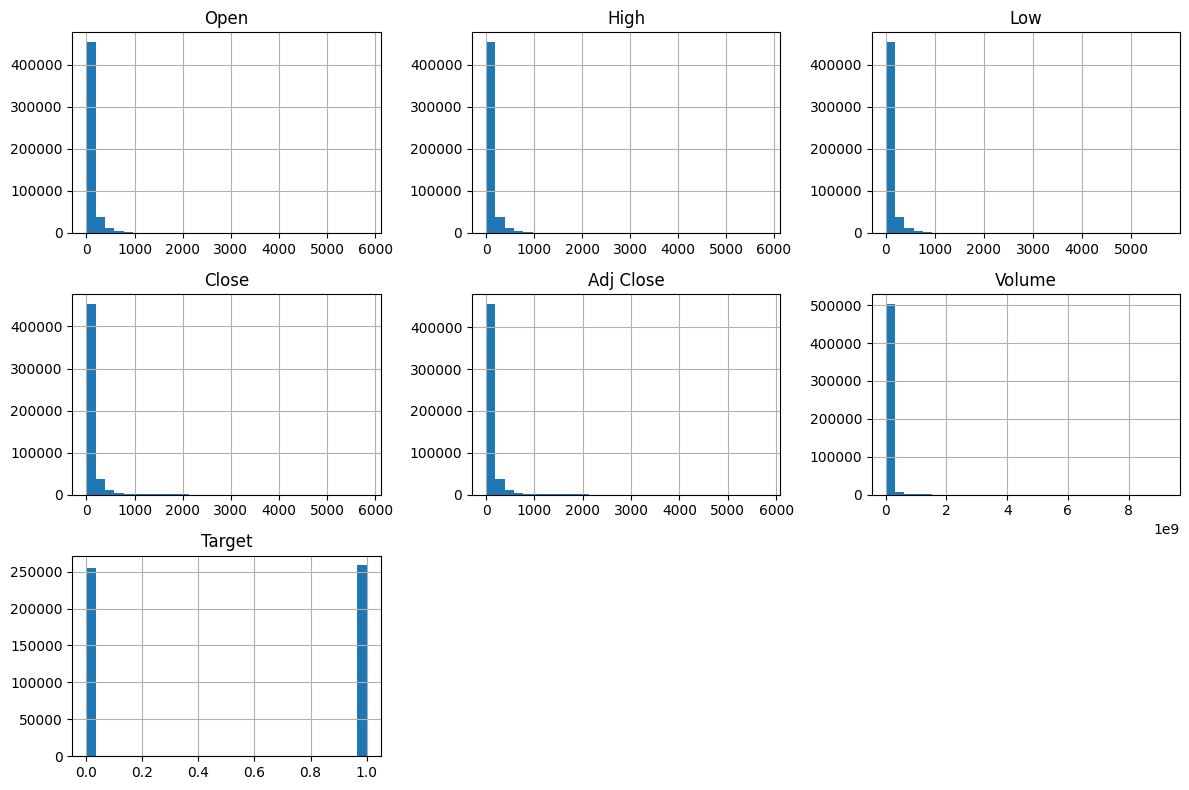

In [12]:
# Histograma de cada variable numérica
import matplotlib.pyplot as plt

df_num.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

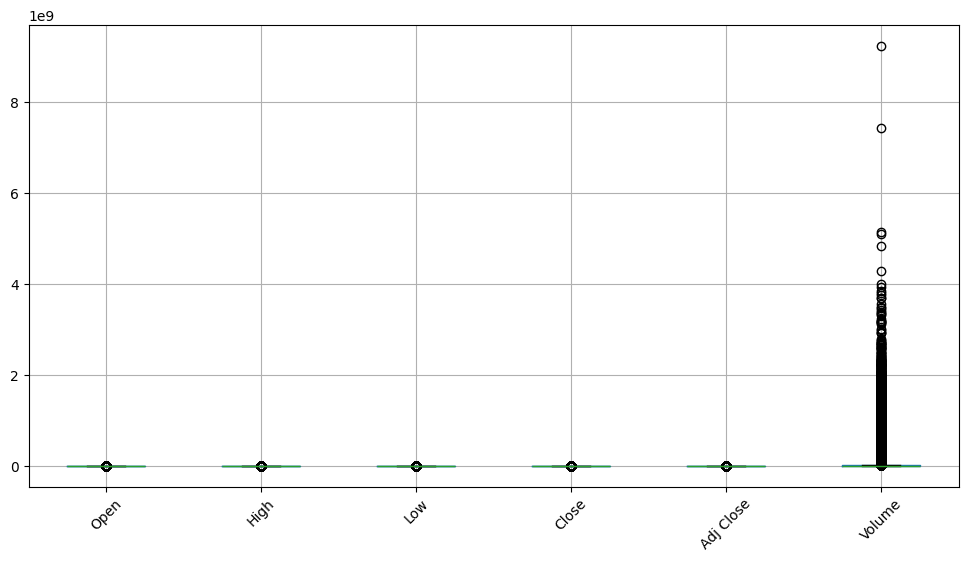

In [13]:
# Boxplots para detectar outliers
plt.figure(figsize=(12, 6))
df_num[["Open", "High", "Low", "Close", "Adj Close", "Volume"]].boxplot()
plt.xticks(rotation=45)
plt.show()

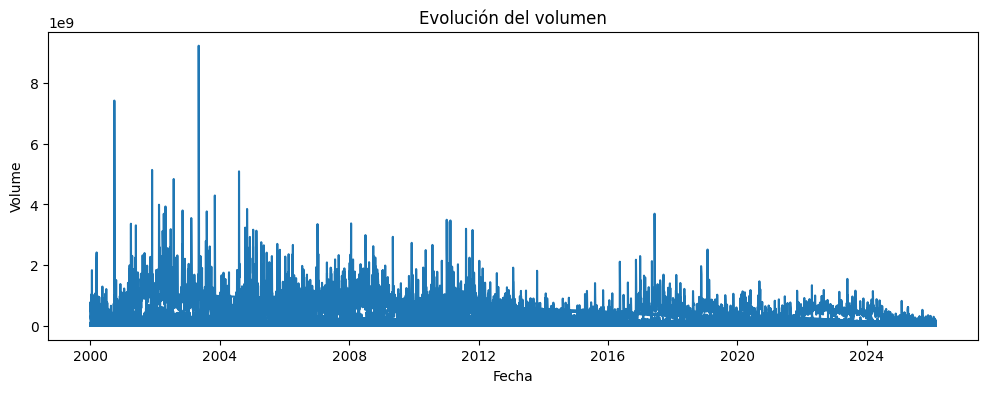

In [14]:
# Distribución temporal del volumen
plt.figure(figsize=(12, 4))
plt.plot(df["Date"], df_num["Volume"])
plt.title("Evolución del volumen")
plt.xlabel("Fecha")
plt.ylabel("Volume")
plt.show()

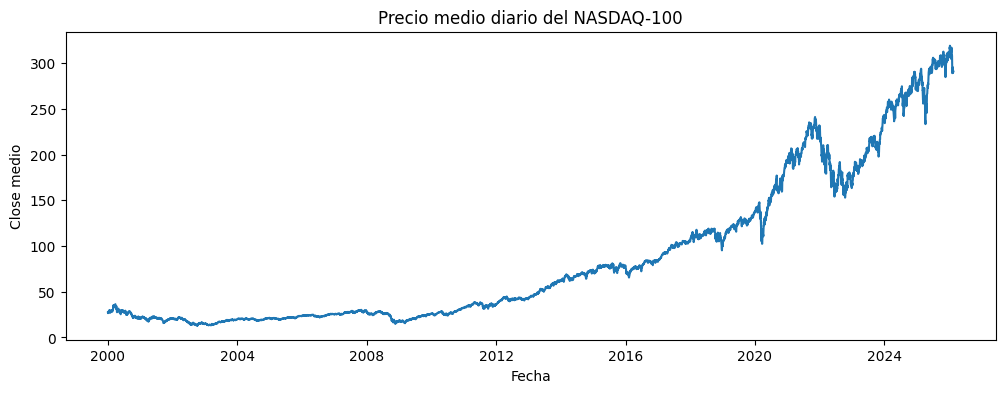

In [15]:
# Distribución temporal del precio de cierre
df_mean = df.groupby("Date")["Close"].mean().reset_index()

plt.figure(figsize=(12, 4))
plt.plot(df_mean["Date"], df_mean["Close"])
plt.title("Precio medio diario del NASDAQ-100")
plt.xlabel("Fecha")
plt.ylabel("Close medio")
plt.show()

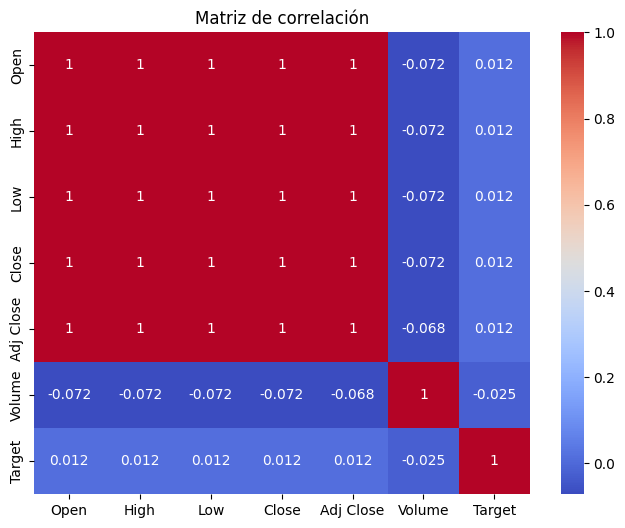

In [16]:
# Correlación entre variables numéricas
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(df_num.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

### 8. Análisis bivariante

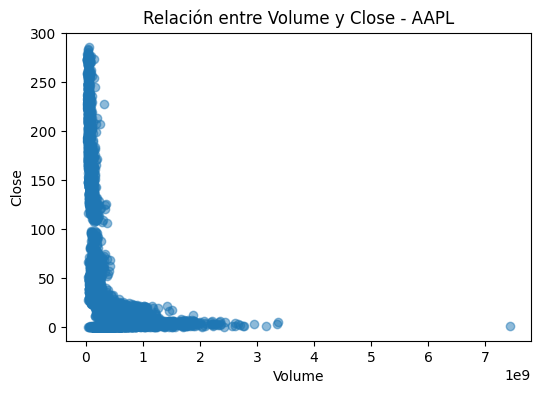

In [17]:

# Relación entre Close y Volume
ticker = "AAPL"
df_ticker = df[df["Ticker"] == ticker]

plt.figure(figsize=(6, 4))
plt.scatter(df_ticker["Volume"], df_ticker["Close"], alpha=0.5)
plt.xlabel("Volume")
plt.ylabel("Close")
plt.title(f"Relación entre Volume y Close - {ticker}")
plt.show()

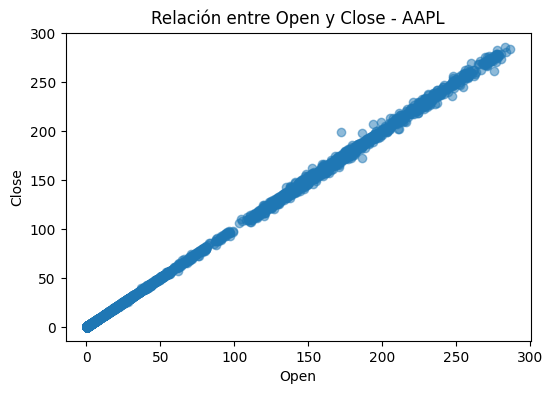

In [18]:
# Relación entre Open y Close
ticker = "AAPL"
df_ticker = df[df["Ticker"] == ticker]

plt.figure(figsize=(6, 4))
plt.scatter(df_ticker["Open"], df_ticker["Close"], alpha=0.5)
plt.xlabel("Open")
plt.ylabel("Close")
plt.title(f"Relación entre Open y Close - {ticker}")
plt.show()

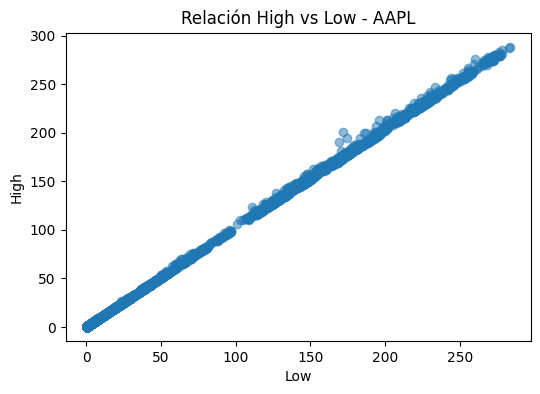

In [19]:
# Relación entre High y Low
ticker = "AAPL"
df_ticker = df[df["Ticker"] == ticker]

plt.figure(figsize=(6, 4))
plt.scatter(df_ticker["Low"], df_ticker["High"], alpha=0.5)
plt.xlabel("Low")
plt.ylabel("High")
plt.title(f"Relación High vs Low - {ticker}")
plt.show()

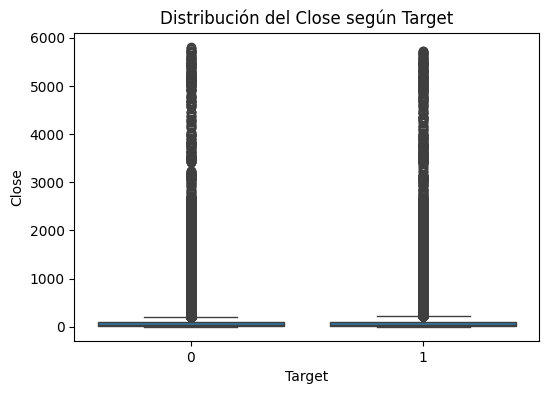

In [20]:
# Distribución del Close en función del Target (Sube/Baja al día siguiente)
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.boxplot(x="Target", y="Close", data=df)
plt.title("Distribución del Close según Target")
plt.show()

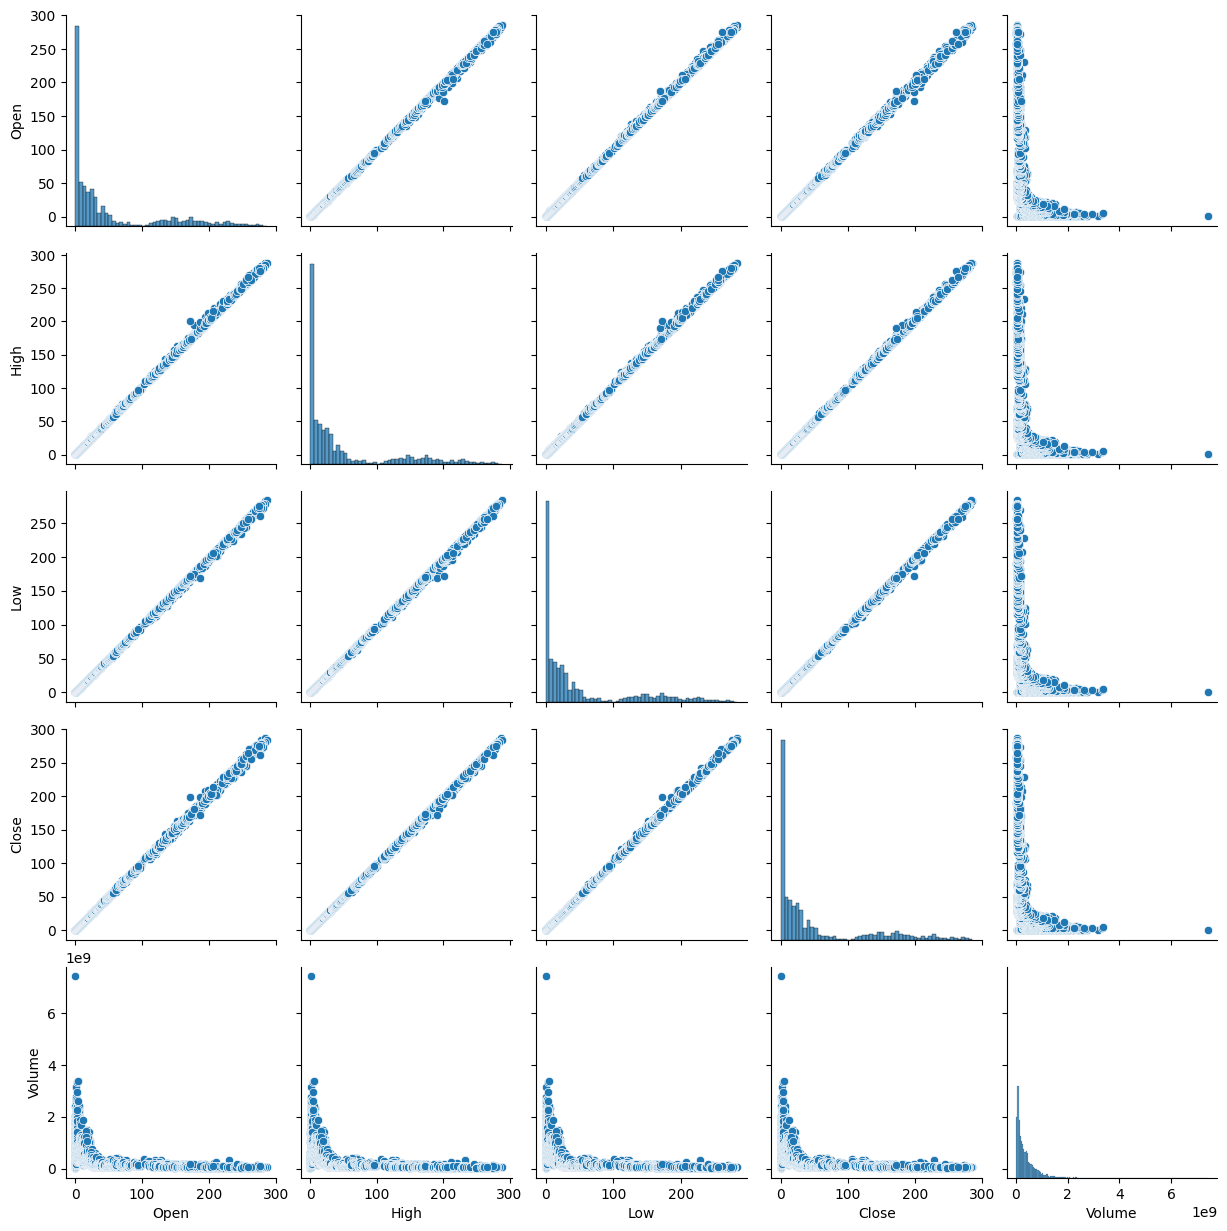

In [21]:
# Correlación par a par entre variables numéricas de un ticker
ticker = "AAPL"
df_ticker = df[df["Ticker"] == ticker]

sns.pairplot(df_ticker[["Open", "High", "Low", "Close", "Volume"]])
plt.show()


In [22]:
# Correlación específica entre cada variable y el Target
df_num.corr()["Target"].sort_values(ascending=False)

Target       1.000000
Low          0.012434
Open         0.012420
High         0.012386
Close        0.012313
Adj Close    0.012213
Volume      -0.024930
Name: Target, dtype: float64

In [23]:
# ver nans
df.isna().sum()

Ticker       0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Target       0
dtype: int64

### 9. Eliminacion Features

In [24]:
# NaNs por columna
na_counts = df.isna().sum()
na_percent = (df.isna().mean() * 100).round(2)

na_counts, na_percent

(Ticker       0
 Date         0
 Open         0
 High         0
 Low          0
 Close        0
 Adj Close    0
 Volume       0
 Target       0
 dtype: int64,
 Ticker       0.0
 Date         0.0
 Open         0.0
 High         0.0
 Low          0.0
 Close        0.0
 Adj Close    0.0
 Volume       0.0
 Target       0.0
 dtype: float64)

### 10. Duplicados

In [25]:
# Número de filas duplicadas
df.duplicated().sum()

np.int64(0)

### 11. Missings

In [26]:
# Número de NaNs por columna
df.isna().sum()

Ticker       0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Target       0
dtype: int64

In [27]:
df.dtypes

Ticker               object
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
Target                int64
dtype: object

### 12. Anomalías y Errores

In [28]:
# Valores negativos en precios o volumen (no deberían existir)
(df_num < 0).sum()


Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Target       0
dtype: int64

In [29]:
# High debe ser >= Low
df[(df["High"] < df["Low"])]

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume,Target


In [30]:
# Close debe estar entre Low y High
df[(df["Close"] < df["Low"]) | (df["Close"] > df["High"])]

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume,Target


### 13. Outliers

In [31]:
df["return"] = df["Close"].pct_change()
df["return"].head()

0         NaN
1   -0.080000
2    0.010870
3   -0.086022
4    0.047059
Name: return, dtype: float64

In [32]:
import numpy as np

Q1 = df["return"].quantile(0.25)
Q3 = df["return"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR

outliers_returns = df[(df["return"] < lower) | (df["return"] > upper)]
outliers_returns.shape

(10273, 10)

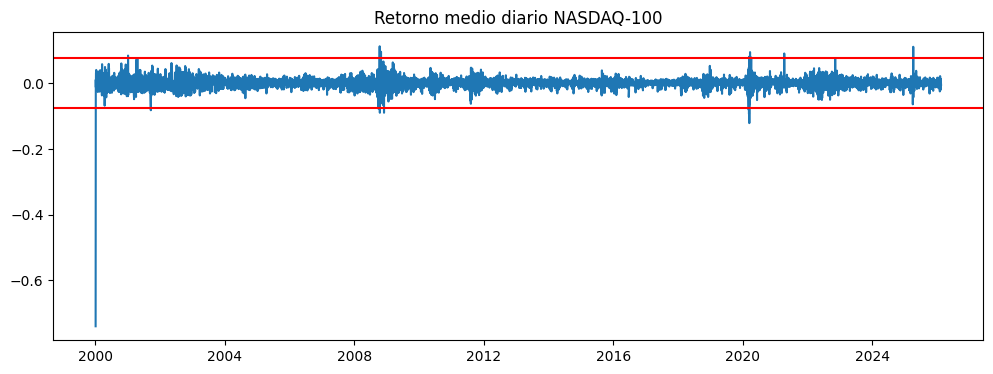

In [33]:
#retorno medio diario
df_mean = df.groupby("Date")["return"].mean().reset_index()

plt.figure(figsize=(12,4))
plt.plot(df_mean["Date"], df_mean["return"])
plt.axhline(lower, color="red")
plt.axhline(upper, color="red")
plt.title("Retorno medio diario NASDAQ-100")
plt.show()

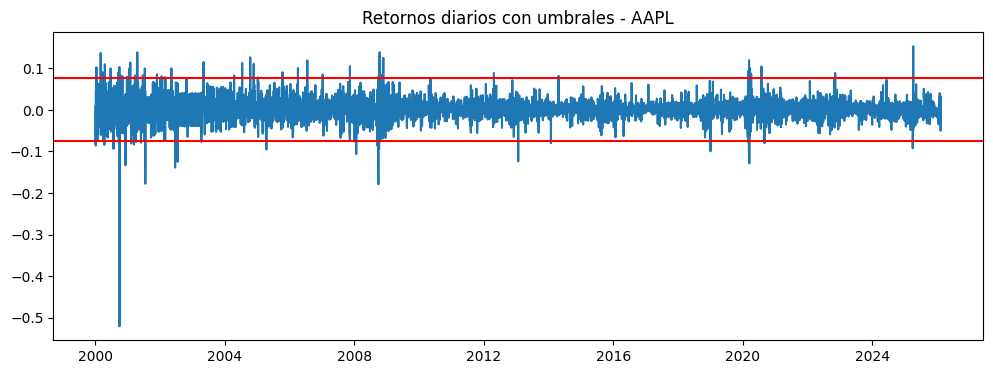

In [34]:
#analizar outliers por ticker
ticker = "AAPL"
df_ticker = df[df["Ticker"] == ticker]

plt.figure(figsize=(12,4))
plt.plot(df_ticker["Date"], df_ticker["return"])
plt.axhline(lower, color="red")
plt.axhline(upper, color="red")
plt.title(f"Retornos diarios con umbrales - {ticker}")
plt.show()

In [35]:
df["Close_diff"] = df["Close"].diff().abs()


In [36]:
threshold = df["Close_diff"].mean() + 3 * df["Close_diff"].std()

In [37]:
anomalous_rows = df[df["Close_diff"] > threshold]
anomalous_rows.shape

(2462, 11)

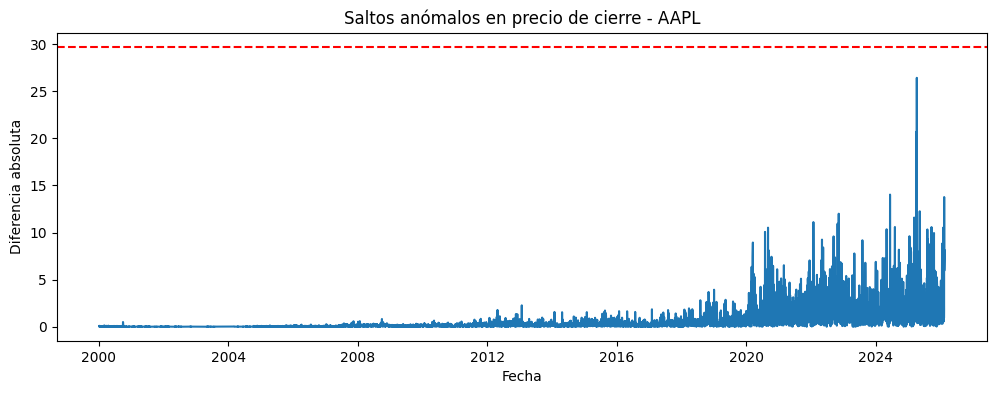

In [38]:
ticker = "AAPL"
df_ticker = df[df["Ticker"] == ticker]

plt.figure(figsize=(12, 4))
plt.plot(df_ticker["Date"], df_ticker["Close_diff"])
plt.axhline(threshold, color="red", linestyle="--")
plt.title(f"Saltos anómalos en precio de cierre - {ticker}")
plt.xlabel("Fecha")
plt.ylabel("Diferencia absoluta")
plt.show()

### 14. Feature engineering

In [39]:
# Retorno simple
df["return"] = df["Close"].pct_change()

# Retorno logarítmico (más estable)
import numpy as np
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

In [40]:
# Lags de precios
df["Close_lag1"] = df["Close"].shift(1)
df["Close_lag2"] = df["Close"].shift(2)
df["Close_lag3"] = df["Close"].shift(3)

# Lags de retornos
df["return_lag1"] = df["return"].shift(1)
df["return_lag2"] = df["return"].shift(2)
df["return_lag3"] = df["return"].shift(3)

In [41]:
# Medias moviles
df["SMA_5"] = df["Close"].rolling(window=5).mean()
df["SMA_10"] = df["Close"].rolling(window=10).mean()
df["SMA_20"] = df["Close"].rolling(window=20).mean()

In [42]:
#volatilidad
df["volatility_5"] = df["return"].rolling(window=5).std()
df["volatility_10"] = df["return"].rolling(window=10).std()
df["volatility_20"] = df["return"].rolling(window=20).std()

In [43]:
#Momentum
df["momentum_5"] = df["Close"] - df["Close"].shift(5)
df["momentum_10"] = df["Close"] - df["Close"].shift(10)

In [44]:
#RSI
window = 14
delta = df["Close"].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=window).mean()
avg_loss = loss.rolling(window=window).mean()

rs = avg_gain / avg_loss
df["RSI"] = 100 - (100 / (1 + rs))

In [45]:
#MACD
df["EMA_12"] = df["Close"].ewm(span=12, adjust=False).mean()
df["EMA_26"] = df["Close"].ewm(span=26, adjust=False).mean()

df["MACD"] = df["EMA_12"] - df["EMA_26"]
df["MACD_signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

In [46]:
df_fe = df.dropna().copy()
df_fe.head()


,Ticker,Date,Open,High,Low,Close,Adj Close,Volume,Target,return,...,volatility_5,volatility_10,volatility_20,momentum_5,momentum_10,RSI,EMA_12,EMA_26,MACD,MACD_signal
20,AAPL,2000-02-01,0.93,0.94,0.89,0.90,0.75,318035200,0,-0.032258,...,0.035202,0.042441,0.052382,-0.10,-0.03,56.603774,0.938587,0.944528,-0.005941,-0.006995
21,AAPL,2000-02-02,0.90,0.91,0.87,0.88,0.74,464195200,1,-0.022222,...,0.035211,0.041947,0.049480,-0.10,-0.07,60.000000,0.929574,0.939748,-0.010175,-0.007631
22,AAPL,2000-02-03,0.90,0.93,0.90,0.92,0.77,475193600,1,0.045455,...,0.046102,0.038930,0.050512,-0.06,-0.09,56.521739,0.928101,0.938285,-0.010185,-0.008142
23,AAPL,2000-02-04,0.93,0.98,0.93,0.96,0.81,425320000,1,0.043478,...,0.036528,0.041935,0.046993,0.05,-0.03,56.521739,0.933008,0.939894,-0.006886,-0.007890
24,AAPL,2000-02-07,0.96,1.02,0.95,1.02,0.85,441067200,1,0.062500,...,0.043351,0.044109,0.047803,0.09,0.07,59.183673,0.946392,0.945828,0.000564,-0.006200


In [47]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 513418 entries, 20 to 514073
Data columns (total 31 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Ticker         513418 non-null  object        
 1   Date           513418 non-null  datetime64[ns]
 2   Open           513418 non-null  float64       
 3   High           513418 non-null  float64       
 4   Low            513418 non-null  float64       
 5   Close          513418 non-null  float64       
 6   Adj Close      513418 non-null  float64       
 7   Volume         513418 non-null  int64         
 8   Target         513418 non-null  int64         
 9   return         513418 non-null  float64       
 10  Close_diff     513418 non-null  float64       
 11  log_return     513418 non-null  float64       
 12  Close_lag1     513418 non-null  float64       
 13  Close_lag2     513418 non-null  float64       
 14  Close_lag3     513418 non-null  float64       
 15  retu

### 15. Feature reduction

--- Iniciando Reducción de Features ---
1. Variables eliminadas por ser casi idénticas a otras (>95% correlación):
['High', 'Low', 'Close', 'Adj Close', 'Close_lag1', 'Close_lag2', 'Close_lag3', 'SMA_5', 'SMA_10', 'SMA_20', 'EMA_12', 'EMA_26', 'MACD_signal']

2. Calculando importancia de las variables restantes con Random Forest...


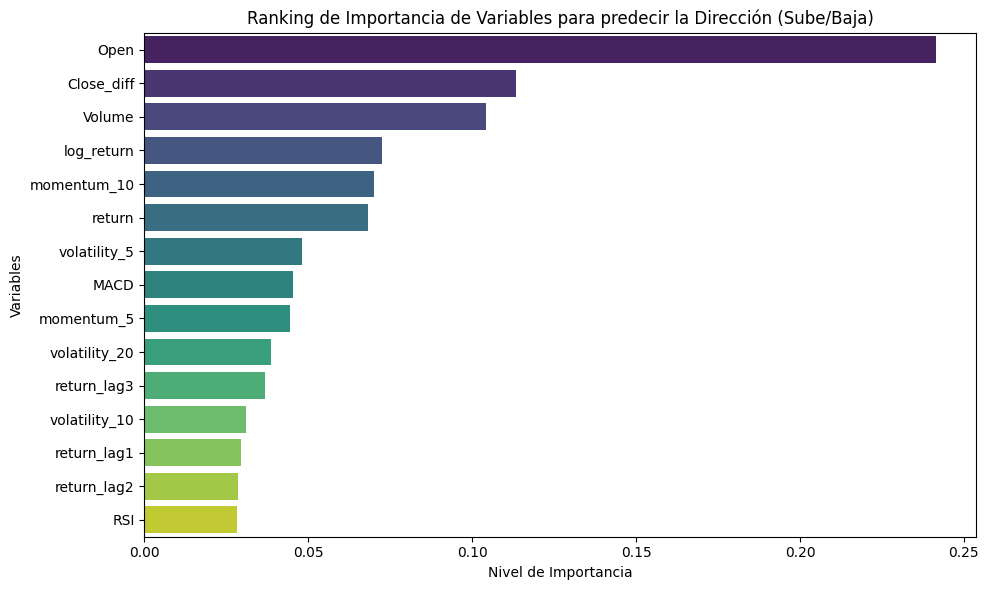


3. Variables ganadoras (seleccionadas para el modelo final):
['Open', 'Close_diff', 'Volume', 'log_return', 'momentum_10', 'return', 'volatility_5', 'MACD', 'momentum_5', 'volatility_20', 'return_lag3', 'volatility_10', 'return_lag1', 'return_lag2', 'RSI']

--- Resumen del nuevo DataFrame optimizado (df_model_ready) ---
<class 'pandas.core.frame.DataFrame'>
Index: 513418 entries, 20 to 514073
Data columns (total 18 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Ticker         513418 non-null  object        
 1   Date           513418 non-null  datetime64[ns]
 2   Open           513418 non-null  float64       
 3   Close_diff     513418 non-null  float64       
 4   Volume         513418 non-null  int64         
 5   log_return     513418 non-null  float64       
 6   momentum_10    513418 non-null  float64       
 7   return         513418 non-null  float64       
 8   volatility_5   513418 non-null  float64      

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# -------------------------------------------------------------------------
# PASO 15.1: ELIMINACIÓN POR ALTA CORRELACIÓN (Multicolinealidad)
# -------------------------------------------------------------------------

print("--- Iniciando Reducción de Features ---")

# 1. Separamos las variables identificativas y el Target. No queremos reducirlas.
cols_to_exclude = ['Ticker', 'Date', 'Target'] 
features = df_fe.drop(columns=cols_to_exclude)
target = df_fe['Target'].astype(int)

# 2. Calculamos la matriz de correlación (cómo de parecidas son las variables entre sí)
corr_matrix = features.corr().abs()

# 3. Seleccionamos solo el triángulo superior de la matriz para no borrar variables dobles
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 4. Buscamos columnas con una correlación mayor al 95% (son prácticamente idénticas)
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]
print(f"1. Variables eliminadas por ser casi idénticas a otras (>95% correlación):\n{to_drop_corr}\n")

# 5. Creamos un nuevo dataframe sin esas variables redundantes
features_reduced = features.drop(columns=to_drop_corr)


# -------------------------------------------------------------------------
# PASO 15.2: SELECCIÓN POR IMPORTANCIA (Random Forest Feature Importance)
# -------------------------------------------------------------------------

# 6. Usamos un Random Forest rápido, muestra del 20%.
print("2. Calculando importancia de las variables restantes con Random Forest...")
rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)

sample_idx = features_reduced.sample(frac=0.2, random_state=42).index
rf.fit(features_reduced.loc[sample_idx], target.loc[sample_idx])

# 7. Extraemos la "nota" de importancia que el modelo le da a cada variable
importances = rf.feature_importances_
feature_names = features_reduced.columns

df_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importances = df_importances.sort_values(by='Importance', ascending=False)

# 8. Visualizamos cuáles son las estrellas de nuestro dataset
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importances, hue='Feature', palette='viridis', legend=False)
plt.title('Ranking de Importancia de Variables para predecir la Dirección (Sube/Baja)')
plt.xlabel('Nivel de Importancia')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

# 9. Nos quedamos SOLO con las variables que tienen un impacto real (importancia > 0.005)
features_finales = df_importances[df_importances['Importance'] > 0.005]['Feature'].tolist()
print(f"\n3. Variables ganadoras (seleccionadas para el modelo final):\n{features_finales}\n")

# -------------------------------------------------------------------------
# DATASET FINAL LISTO PARA EL MODELO
# -------------------------------------------------------------------------

# Volvemos a pegar las columnas identificativas, nuestras "features ganadoras" y el Target.
df_model_ready = df_fe[['Ticker', 'Date'] + features_finales + ['Target']]

print("--- Resumen del nuevo DataFrame optimizado (df_model_ready) ---")
df_model_ready.info()

In [49]:
# -------------------------------------------------------------------------
# PASO 16: ELECCIÓN DE MÉTRICAS DE EVALUACIÓN (Clasificación)
# -------------------------------------------------------------------------
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Creamos una función maestra para evaluar todos los modelos que probemos después
def evaluar_modelo(y_true, y_pred, y_proba=None, nombre_modelo="Modelo"):
    """
    Calcula y muestra las métricas de negocio para nuestro Sistema de Trading.
    """
    # 1. Accuracy (Acierto global)
    acc = accuracy_score(y_true, y_pred)
    
    # 2. Precision (Acierto cuando el modelo predice compra: Target=1)
    precision = precision_score(y_true, y_pred, zero_division=0)
    
    # 3. Recall (Cuántas subidas reales detecta el modelo)
    recall = recall_score(y_true, y_pred, zero_division=0)
    
    # 4. F1 (Equilibrio entre Precision y Recall)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # Imprimimos los resultados con un formato limpio
    print(f"--- Resultados para: {nombre_modelo} ---")
    print(f"Accuracy  (Acierto global):      {acc*100:.2f}%")
    print(f"Precision (Acierto en compras):  {precision*100:.2f}%")
    print(f"Recall    (Detección de subidas):{recall*100:.2f}%")
    print(f"F1 Score  (Equilibrio):          {f1*100:.2f}%")

    # 5. ROC-AUC (Calidad de ranking si tenemos probabilidades)
    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
        print(f"ROC-AUC   (Ranking):             {auc:.4f}")

    # 6. Matriz de confusión (resumen de aciertos/errores)
    print("\nMatriz de confusión:")
    print(confusion_matrix(y_true, y_pred))
    print()

print("Función de evaluación de métricas definida con éxito. Lista para usar en el entrenamiento.")

Función de evaluación de métricas definida con éxito. Lista para usar en el entrenamiento.


In [50]:
# -------------------------------------------------------------------------
# PASO 17: SELECCIÓN DE MODELOS DE MACHINE LEARNING (Clasificación)
# -------------------------------------------------------------------------

# Importamos los algoritmos elegidos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

print("--- Inicializando Modelos para el Sistema de Trading ---")

# 1. Modelo Base (Logistic Regression)
# No requiere apenas hiperparámetros.
modelo_lr = LogisticRegression(max_iter=1000, n_jobs=-1)
print("1. Regresión Logística: Cargada (Modelo Baseline)")

# 2. Modelo Robusto (Random Forest)
# Le ponemos n_jobs=-1 para que use todos los núcleos de tu procesador y sea más rápido.
# random_state=42 asegura que si lo ejecutas 100 veces, siempre dé el mismo resultado.
modelo_rf = RandomForestClassifier(random_state=42, n_jobs=-1)
print("2. Random Forest: Cargado (Modelo Robusto)")

# 3. Modelo Avanzado (XGBoost)
# objective='binary:logistic' es la configuración estándar para clasificación binaria
modelo_xgb = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42, n_jobs=-1)
print("3. XGBoost: Cargado (Modelo Avanzado / Estado del Arte)")

# Guardamos los modelos en un diccionario para poder iterar sobre ellos fácilmente en el futuro
modelos = {
    "Regresion_Logistica": modelo_lr,
    "Random_Forest": modelo_rf,
    "XGBoost": modelo_xgb
}

print("\nLos 3 modelos están listos para la fase de entrenamiento y optimización")

--- Inicializando Modelos para el Sistema de Trading ---
1. Regresión Logística: Cargada (Modelo Baseline)
2. Random Forest: Cargado (Modelo Robusto)
3. XGBoost: Cargado (Modelo Avanzado / Estado del Arte)

Los 3 modelos están listos para la fase de entrenamiento y optimización


In [51]:
# -------------------------------------------------------------------------
# PASO 18 y 19: PREPARACIÓN, HIPERPARÁMETROS Y ENTRENAMIENTO (PIPELINE)
# -------------------------------------------------------------------------

import time
import numpy as np
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print("--- Iniciando Preparación de Datos ---") 

# 1. DIVISIÓN TEMPORAL (Crucial en Finanzas)
# Ordenamos por Ticker y fecha para respetar la estructura de series temporales por empresa
df_model_ready = df_model_ready.sort_values(by=['Ticker', 'Date'])

# Calculamos el punto de corte por fecha (80% pasado para entrenar, 20% futuro para testear)
split_date = df_model_ready['Date'].quantile(0.8)

train_df = df_model_ready[df_model_ready['Date'] < split_date]
test_df = df_model_ready[df_model_ready['Date'] >= split_date]

# Separamos las variables predictoras (X) de lo que queremos adivinar (y = Target)
# Quitamos Fecha y Ticker porque los modelos matemáticos solo entienden números
X_train = train_df.drop(columns=['Date', 'Ticker', 'Target'])
y_train = train_df['Target'].astype(int)

X_test = test_df.drop(columns=['Date', 'Ticker', 'Target'])
y_test = test_df['Target'].astype(int)

print(f"Fecha de corte (80/20): {split_date.date()}")
print(f"Datos de Entrenamiento (Pasado): {len(X_train)} filas")
print(f"Datos de Test (Futuro): {len(X_test)} filas\n")


# 2. DEFINICIÓN DE HIPERPARÁMETROS (Paso 18)
# Configuramos los modelos con parámetros robustos para evitar sobreajuste (Overfitting)
# y asegurar que entrenan en un tiempo razonable en un PC doméstico.

modelo_lr = LogisticRegression(max_iter=1000, n_jobs=-1)  # Modelo baseline para clasificación

modelo_rf = RandomForestClassifier(
    n_estimators=200,      # Número de árboles
    max_depth=10,          # Profundidad máxima para que no memorice los datos
    min_samples_split=50,  # Mínimo de datos para crear una nueva rama
    random_state=42,
    n_jobs=-1              # Usa toda la potencia de tu PC
)

modelo_xgb = xgb.XGBClassifier(
    n_estimators=300,      # Número de rondas de aprendizaje
    learning_rate=0.05,    # Ritmo de aprendizaje
    max_depth=6,           # Complejidad de las decisiones
    subsample=0.8,         # Usa el 80% de datos por árbol para dar más variedad
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Creamos el diccionario "Pipeline"
pipeline_modelos = {
    "1. Regresión Logística (Baseline)": modelo_lr,
    "2. Random Forest (Robusto)": modelo_rf,
    "3. XGBoost (Avanzado)": modelo_xgb
}


# 3. ENTRENAMIENTO Y EVALUACIÓN (Paso 19)
print("--- Iniciando la Competición de Algoritmos (Entrenamiento) ---")

# Guardaremos las predicciones para el paso final
predicciones = {}

for nombre, modelo in pipeline_modelos.items():
    print(f"\nEntrenando {nombre}...")
    start_time = time.time()
    
    # ENTRENAMIENTO
    modelo.fit(X_train, y_train)
    
    # PREDICCIÓN SOBRE DATOS NO VISTOS (Test)
    y_pred = modelo.predict(X_test)
    predicciones[nombre] = y_pred
    
    tiempo_total = time.time() - start_time
    print(f"¡Entrenamiento completado en {tiempo_total:.2f} segundos!")
    
    # PROBABILIDADES (para ROC-AUC si el modelo las soporta)
    y_proba = None
    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test)[:, 1]
    
    # EVALUACIÓN (Llamamos a la función que creaste en el Paso 16)
    evaluar_modelo(y_test, y_pred, y_proba=y_proba, nombre_modelo=nombre)

print("\n--- Competición Finalizada ---")

--- Iniciando Preparación de Datos ---
Fecha de corte (80/20): 2022-01-03
Datos de Entrenamiento (Pasado): 410695 filas
Datos de Test (Futuro): 102723 filas

--- Iniciando la Competición de Algoritmos (Entrenamiento) ---

Entrenando 1. Regresión Logística (Baseline)...


c:\Users\lllse\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


¡Entrenamiento completado en 1.26 segundos!
--- Resultados para: 1. Regresión Logística (Baseline) ---
Accuracy  (Acierto global):      51.01%
Precision (Acierto en compras):  51.19%
Recall    (Detección de subidas):91.84%
F1 Score  (Equilibrio):          65.74%
ROC-AUC   (Ranking):             0.5002

Matriz de confusión:
[[ 4107 46039]
 [ 4289 48288]]


Entrenando 2. Random Forest (Robusto)...
¡Entrenamiento completado en 40.11 segundos!
--- Resultados para: 2. Random Forest (Robusto) ---
Accuracy  (Acierto global):      51.07%
Precision (Acierto en compras):  51.39%
Recall    (Detección de subidas):81.39%
F1 Score  (Equilibrio):          63.00%
ROC-AUC   (Ranking):             0.5080

Matriz de confusión:
[[ 9664 40482]
 [ 9784 42793]]


Entrenando 3. XGBoost (Avanzado)...
¡Entrenamiento completado en 5.59 segundos!
--- Resultados para: 3. XGBoost (Avanzado) ---
Accuracy  (Acierto global):      51.07%
Precision (Acierto en compras):  51.49%
Recall    (Detección de subidas):75.72%
F1

Los modelos muestran una ligera mejora sobre el azar (Accuracy ≈ 51%, AUC ≈ 0.50–0.51), lo que confirma la dificultad inherente a la predicción de mercados financieros eficientes. La señal predictiva existe, pero es extremadamente débil.

--- Generando Reporte de Resultados ---


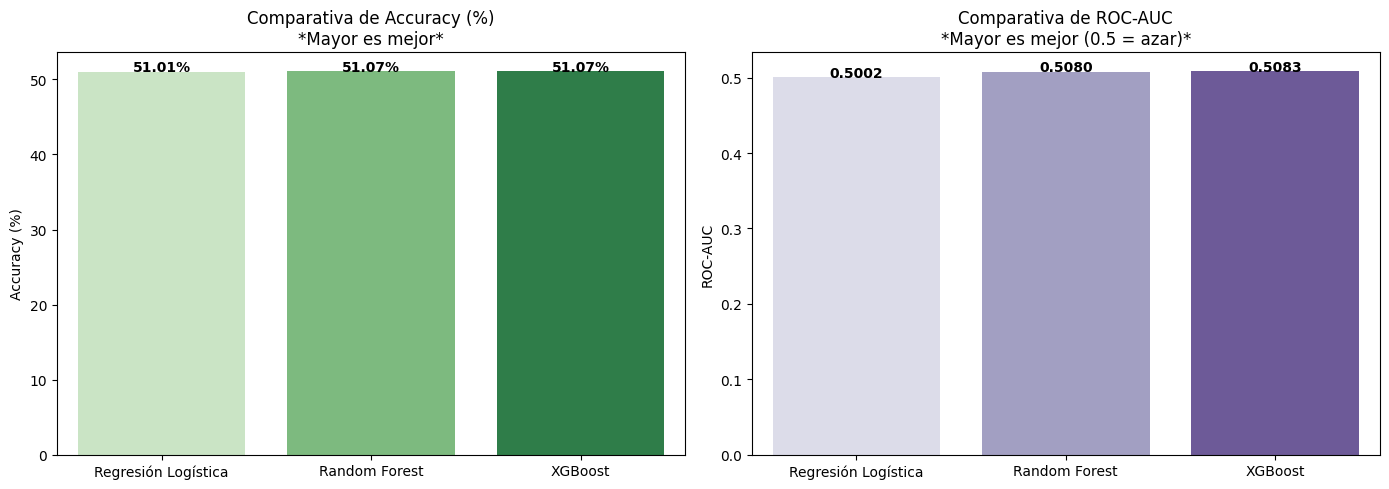

In [52]:
# -------------------------------------------------------------------------
# PASO 20: RESULTADOS (Clasificación)
# -------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Generando Reporte de Resultados ---")

# 1. Recopilamos las métricas clave de clasificación para graficarlas
nombres_modelos = ["Regresión Logística", "Random Forest", "XGBoost"]

accuracies = [51.01, 51.07, 51.07]
precisions = [51.19, 51.39, 51.49]
recalls = [91.84, 81.39, 75.72]
f1s = [65.74, 63.00, 61.30]
aucs = [0.5002, 0.5080, 0.5083]

# 2. Creamos una figura con dos subgráficos (los más informativos)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Comparativa de Accuracy (Mayor es mejor)
sns.barplot(x=nombres_modelos, y=accuracies, ax=ax[0], palette="Greens", hue=nombres_modelos, legend=False)
ax[0].set_title("Comparativa de Accuracy (%)\n*Mayor es mejor*")
ax[0].set_ylabel("Accuracy (%)")
for i, v in enumerate(accuracies):
    ax[0].text(i, v + 0.1, f"{v:.2f}%", ha='center', fontweight='bold')

# Gráfico 2: Comparativa de ROC-AUC (Mayor es mejor)
sns.barplot(x=nombres_modelos, y=aucs, ax=ax[1], palette="Purples", hue=nombres_modelos, legend=False)
ax[1].set_title("Comparativa de ROC-AUC\n*Mayor es mejor (0.5 = azar)*")
ax[1].set_ylabel("ROC-AUC")
for i, v in enumerate(aucs):
    ax[1].text(i, v + 0.001, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
#20. 1. Evaluar los resultados en test:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

resultados = []

for nombre, modelo in pipeline_modelos.items():
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    y_proba_train = None
    y_proba_test = None
    if hasattr(modelo, "predict_proba"):
        y_proba_train = modelo.predict_proba(X_train)[:, 1]
        y_proba_test = modelo.predict_proba(X_test)[:, 1]

    fila = {
        "Modelo": nombre,
        "Accuracy_train": accuracy_score(y_train, y_pred_train),
        "Accuracy_test": accuracy_score(y_test, y_pred_test),
        "Precision_test": precision_score(y_test, y_pred_test, zero_division=0),
        "Recall_test": recall_score(y_test, y_pred_test, zero_division=0),
        "F1_test": f1_score(y_test, y_pred_test, zero_division=0),
    }

    if y_proba_test is not None:
        fila["AUC_train"] = roc_auc_score(y_train, y_proba_train)
        fila["AUC_test"] = roc_auc_score(y_test, y_proba_test)

    resultados.append(fila)

resultados_df = pd.DataFrame(resultados)

orden = ["AUC_test", "Accuracy_test"]
orden = [c for c in orden if c in resultados_df.columns]
if orden:
    resultados_df = resultados_df.sort_values(by=orden, ascending=False)

resultados_df

,Modelo,Accuracy_train,Accuracy_test,Precision_test,Recall_test,F1_test,AUC_train,AUC_test
2,3. XGBoost (Avanzado),0.578948,0.510665,0.514947,0.757156,0.612993,0.618258,0.508307
1,2. Random Forest (Robusto),0.549478,0.510665,0.513876,0.813911,0.629994,0.576098,0.508028
0,1. Regresión Logística (Baseline),0.511713,0.510061,0.511921,0.918424,0.657409,0.519560,0.500224


### ¿Por qué no se aplican medidas adicionales de corrección del overfitting?

Tras comparar el rendimiento en entrenamiento y test, se observa una ligera caída en los modelos más complejos (Random Forest y XGBoost). Sin embargo, esta diferencia no es extrema y se mantiene dentro de un rango esperable en problemas financieros.

Por ejemplo:

- XGBoost: AUC_train ≈ 0.62 → AUC_test ≈ 0.51  
- Random Forest: AUC_train ≈ 0.57 → AUC_test ≈ 0.51  
- Regresión Logística: comportamiento prácticamente estable  

Esto indica que existe cierto grado de sobreajuste, pero no un sobreentrenamiento severo. 

En este contexto, aplicar técnicas adicionales como:

- Reducir profundidad de árboles
- Aumentar regularización
- Eliminar más variables
- Aplicar PCA

No resolvería el problema principal, ya que la limitación observada no proviene de un modelo excesivamente complejo, sino de la **escasa señal predictiva estable presente en los datos**.

Forzar mayor regularización probablemente reduciría el rendimiento en entrenamiento sin generar una mejora significativa en test, dado que el AUC ya se encuentra muy cercano al azar (0.5).

Por tanto, la decisión metodológica adoptada es:

- Reconocer la ligera pérdida de generalización.
- Aceptar que el problema es intrínsecamente complejo.
- No introducir ajustes adicionales que no aporten mejoras estructurales reales.

El foco pasa a centrarse en la interpretación de negocio y en posibles mejoras estructurales (más datos, nuevas variables, validación walk-forward), en lugar de microajustes técnicos del modelo.

## 20.2 Evaluación de Resultados desde la Perspectiva de Negocio

El objetivo del proyecto no es únicamente obtener buenas métricas estadísticas, sino evaluar si el modelo podría aportar valor en un contexto real de trading.

### ¿Es suficiente un 51% de Accuracy?

Un accuracy cercano al 51% implica una ventaja estadística muy reducida frente al azar (50%). Aunque matemáticamente es superior, en mercados financieros esta diferencia es extremadamente pequeña.

En un entorno real, esta ligera ventaja podría verse anulada por:

- Costes de transacción
- Comisiones de intermediación
- Slippage (diferencia entre precio esperado y ejecutado)
- Impacto de mercado en órdenes grandes

Por tanto, una precisión del 51% no garantiza rentabilidad.

---

### Evaluación del Riesgo Operativo

Los modelos muestran una alta tasa de predicción de subidas (recall elevado), lo que implica que el sistema generaría muchas señales de compra.

Esto podría traducirse en:

- Alta rotación de cartera
- Incremento de costes
- Mayor exposición a movimientos adversos

Sin una estrategia adicional de gestión del riesgo (stop loss, position sizing, filtros adicionales), el modelo no sería suficiente para operar de forma automática.

---

### Conclusión desde Negocio

Aunque el sistema detecta una señal ligeramente superior al azar, esta no es lo suficientemente robusta como para justificar su uso directo en producción.

El valor del proyecto reside en:

- La correcta metodología aplicada
- La validación temporal sin fuga de información
- La evaluación rigurosa de generalización

Desde una perspectiva empresarial, sería necesario:

- Mejorar la señal predictiva
- Incorporar más fuentes de información
- Simular una estrategia completa incluyendo costes reales

In [54]:
#20.3 elegir modelo ganador:
metric_key = "AUC_test" if "AUC_test" in resultados_df.columns else "Accuracy_test"
best_model_name = resultados_df.sort_values(by=metric_key, ascending=False).iloc[0]["Modelo"]
best_model = pipeline_modelos[best_model_name]

print("Modelo ganador:", best_model_name)
print("Métrica usada:", metric_key, "=", resultados_df.sort_values(by=metric_key, ascending=False).iloc[0][metric_key])

Modelo ganador: 3. XGBoost (Avanzado)
Métrica usada: AUC_test = 0.5083073938924216


In [55]:
#Guardar modelo
import pickle

with open("finished_model.model", "wb") as archivo_salida:
    pickle.dump(best_model, archivo_salida)

print("Modelo guardado como: finished_model.model")

Modelo guardado como: finished_model.model


In [57]:
#Almacenar muestras usadas:
train_df[["Ticker", "Date"]].to_csv("train_samples.csv", index=False)
test_df[["Ticker", "Date"]].to_csv("test_samples.csv", index=False)

print("Muestras de entrenamiento y test guardadas correctamente.")

Muestras de entrenamiento y test guardadas correctamente.


In [56]:
# Para volver a leer el modelo
with open('finished_model.model', "rb") as archivo_entrada:
    pipeline_importada = pickle.load(archivo_entrada)
    
print(pipeline_importada)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)


#  Conclusiones del Proyecto:

## 1. Resultado Principal

El objetivo del proyecto ha sido evaluar si es posible predecir la **dirección diaria del precio (sube/baja)** de acciones del NASDAQ-100 utilizando exclusivamente información histórica de mercado e indicadores técnicos.

Los resultados obtenidos muestran un rendimiento ligeramente superior al azar:

- **Accuracy ≈ 51%**
- **ROC-AUC ≈ 0.50 – 0.51**

Estos valores indican que la señal predictiva detectada es **muy débil**, lo cual es coherente con la hipótesis de eficiencia de los mercados financieros, especialmente en horizontes temporales diarios.

---

## 2. Comparativa de Modelos

Entre los modelos evaluados:

- **XGBoost** y **Random Forest** presentan el mejor rendimiento en términos de ROC-AUC.
- **Regresión Logística** actúa como baseline interpretable, obteniendo resultados similares.

La mejora de los modelos más complejos frente al baseline es marginal, lo que sugiere que aumentar la complejidad del algoritmo no compensa la limitada señal informativa disponible en los datos.

---

## 3. Interpretación desde el Punto de Vista de Negocio

Desde una perspectiva financiera:

- Un accuracy cercano al 51% implica una ventaja estadística muy reducida.
- En condiciones reales, dicha ventaja podría verse erosionada por:
  - Costes de transacción  
  - Slippage  
  - Comisiones  
  - Gestión del riesgo  

Por tanto, aunque el modelo muestra una ligera capacidad predictiva, **no sería suficiente por sí solo para justificar una estrategia de trading automática sin un análisis adicional de rentabilidad ajustada al riesgo**.

---

## 4️. Limitaciones del Estudio

- Se utilizan únicamente variables técnicas derivadas del precio.
- No se incorporan factores macroeconómicos ni fundamentales.
- No se ha realizado validación walk-forward con ventanas móviles.
- No se ha simulado una estrategia completa con métricas financieras (Sharpe ratio, drawdown, etc.).

---

## 5. Líneas Futuras de Mejora

Para aumentar el potencial predictivo y la robustez del sistema, se proponen las siguientes mejoras:

- Implementar validación temporal tipo **walk-forward**.
- Entrenar modelos específicos por **ticker** o por sector.
- Incorporar variables macroeconómicas (tipos de interés, inflación, decisiones de la FED).
- Optimizar el **umbral de decisión** en lugar de utilizar 0.5 fijo.
- Simular una estrategia real comparándola con **Buy & Hold**, incluyendo costes de transacción.

---

## Conclusión Final

El estudio confirma que predecir la dirección diaria del mercado con datos históricos de precios es un problema altamente complejo y con señal limitada.

El valor principal del proyecto reside en la aplicación de una **metodología rigurosa, sin fuga de información y coherente con la naturaleza de los mercados financieros**, más que en la obtención de una alta tasa de acierto.